In [4]:
import RT_utils
from RT_utils import run_RT, plot_rt_summary, load_dat_colormap

import importlib
importlib.reload(RT_utils)
from RT_utils import run_RT, plot_rt_summary, load_dat_colormap

import matplotlib.pyplot as plt
import os
import numpy as np
import tifffile as tiff
from PIL import Image
from pathlib import Path


Size of SSFROG file: (1024, 1024)
Max value of SSFROG file: 59200.0
Saved input TIFF: D:\FROG_RT_Xuyang\Results\SSFROG_May2026\test\test_001.tiff
Selected file: test_001.tiff
Runtime (no plotting): 13.044 s
Final G: 0.00554236
Best G : 0.00554236
Selected file: test_001.tiff
Final G: 0.0055423645600905375
Best G : 0.0055423645600905375


(<Figure size 1800x1000 with 11 Axes>,
 array([[<Axes: title={'center': 'Original Trace'}>,
         <Axes: title={'center': 'Reconstructed Trace'}>,
         <Axes: title={'center': 'Difference'}>],
        [<Axes: title={'center': 'Temporal | FWHM=26.14 fs'}>,
         <Axes: title={'center': 'Spectral | FWHM=36.78 nm'}>,
         <Axes: title={'center': 'G vs Iter | Final=0.005542'}>]],
       dtype=object))

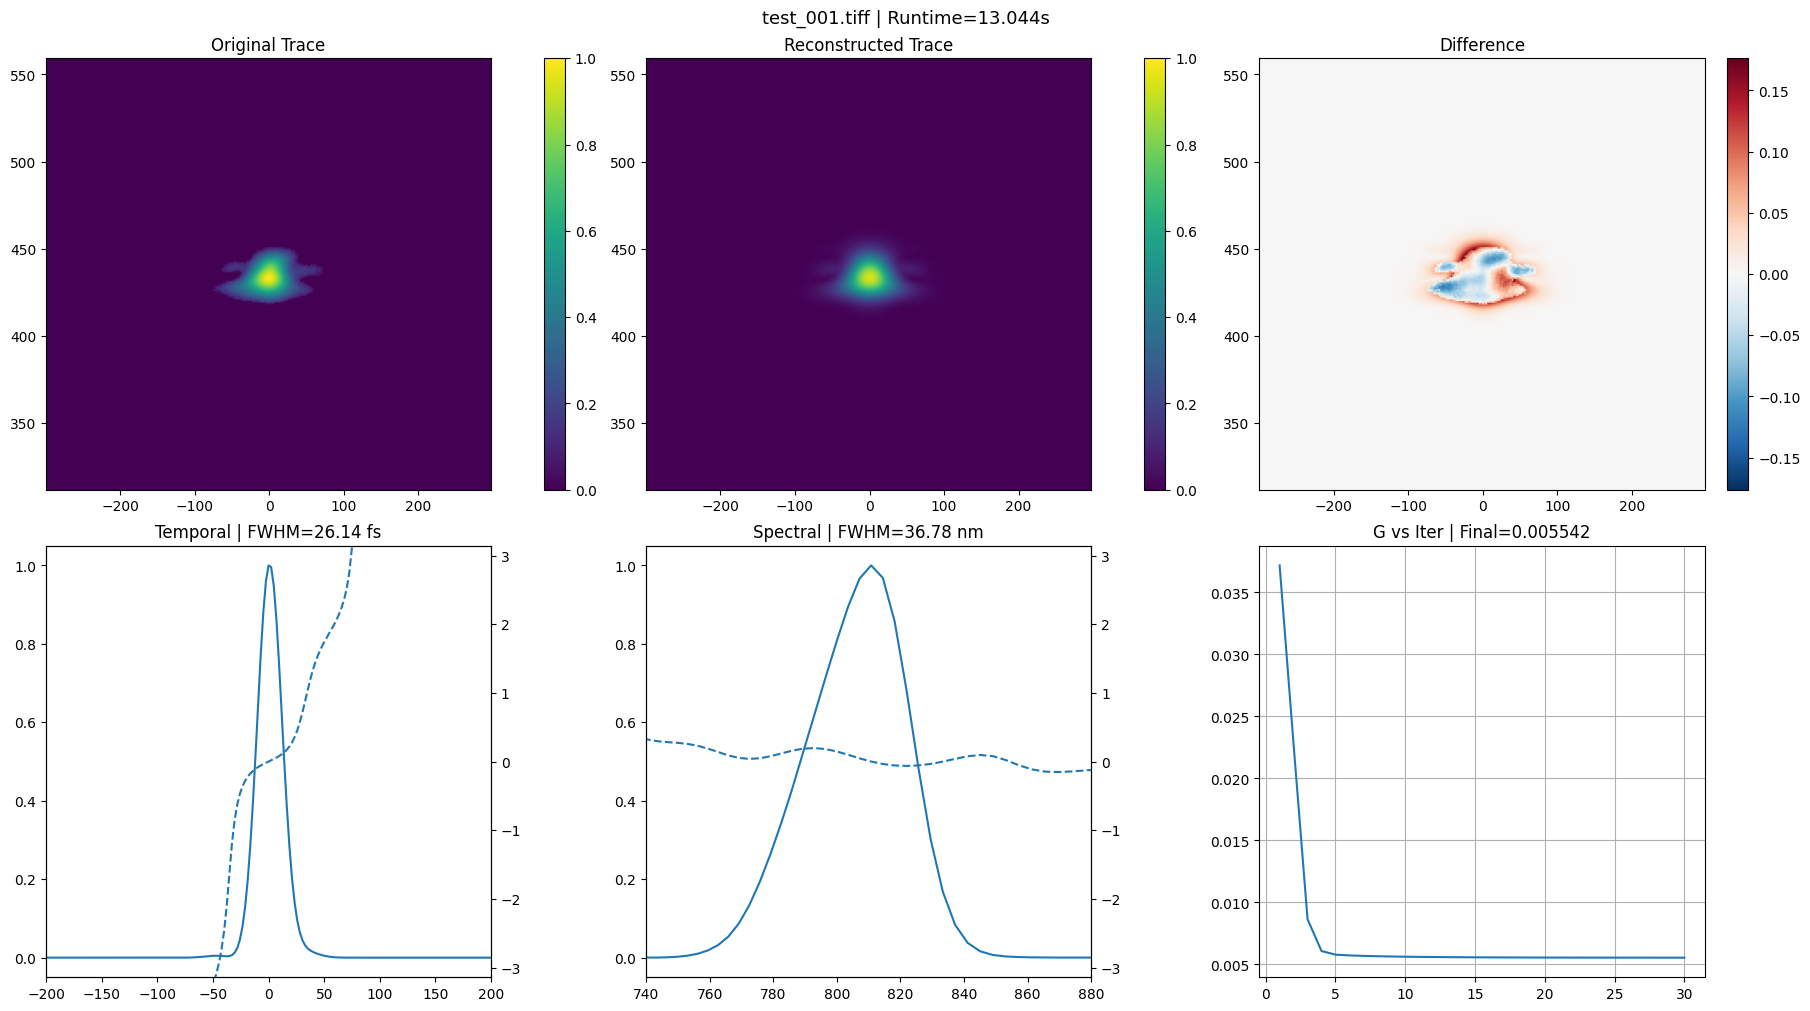

In [5]:
background_file=r"Z:\Data\2026_03_10_FROG\SSFROG_10Hz_50um_1inch_8mJ\Background_Gain28\BKFLY613__24492756__20260311_044808760_0077.tiff"
background_array = tiff.imread(background_file)

def find_latest_file(folder_path, keywords, match_all=True):
    """
    Find the most recently modified file in a folder
    whose name matches one or more keywords.

    :param folder_path: Path to the target folder
    :param keywords: List of substrings to search for in file names
    :param match_all: If True, file name must contain ALL keywords;
                      if False, file name can contain ANY keyword
    :return: Path object of the latest file, or None if not found
    """

    path = Path(folder_path)

    # Normalize keywords to a list (in case a single string is passed)
    if isinstance(keywords, str):
        keywords = [keywords]

    def matches(filename):
        """Check if filename matches keyword condition."""
        if match_all:
            return all(k in filename for k in keywords)
        else:
            return any(k in filename for k in keywords)

    # Collect matching files
    files = [
        f for f in path.iterdir()
        if f.is_file() and matches(f.name)
    ]

    if not files:
        return None

    # Return the file with the latest modification time
    return max(files, key=lambda f: f.stat().st_mtime)

# Example usage
folder = r"Z:\Data\2026_05_10_PlasmaMirrors_PhaseMeasurement\SSFROG_SI_test"
keyword = ["BKFLY613"]

ssfrog_file = find_latest_file(folder, keyword)
img_ssfrog = Image.open(ssfrog_file)
arr_ssfrog = np.array(img_ssfrog)
background_array = tiff.imread(background_file).astype(np.float32)
arr_ssfrog = arr_ssfrog.astype(np.float32)
array_background_removed = arr_ssfrog - background_array
array_background_removed = np.clip(array_background_removed, 1, None)
arr_ssfrog=array_background_removed
#make the x axis 1024, crop the right boundary if necessary
offset = (arr_ssfrog.shape[1] - 1024)/2
arr_ssfrog = arr_ssfrog[:, int(offset):int(offset)+1024].T
#print size and max value of the ssfrog_file
print("Size of SSFROG file:", arr_ssfrog.shape)
print("Max value of SSFROG file:", np.max(arr_ssfrog))
#show it
#plt.imshow(arr_ssfrog, cmap='gray')#perform RT on the selected SSFROG file, and plot the summary of the results.
result, eng = run_RT(
    input_array=arr_ssfrog,
    input_name="test_001",
    input_save_dir=r"D:\FROG_RT_Xuyang\Results\SSFROG_May2026\test",
    matlab_code_dir=r"Z:\Code\Experimental_Analysis\FROG\Frog_Automated",
    max_iter=30,
    plot_iter=30,
    temporal_calibration=0.387225,
    spectral_calibration=0.043919,
    background=5,
    central_wavelength=400,
    sz=256,
    width=70,
    verbose=True
)
#print and directly plot the result
print("Selected file:", result["selected_file"])
print("Final G:", result["final_G"])
print("Best G :", result["best_G"])

plot_rt_summary(result)

Size of SSFROG file: (1024, 1024)
Max value of SSFROG file: 60928.0
Saved input TIFF: D:\FROG_RT_Xuyang\Results\SSFROG_May2026\test\test_001.tiff
Selected file: test_001.tiff
Runtime (no plotting): 8.129 s
Final G: 0.00617421
Best G : 0.00617421
Selected file: test_001.tiff
Final G: 0.00617421017557042
Best G : 0.00617421017557042


(<Figure size 1800x1000 with 11 Axes>,
 array([[<Axes: title={'center': 'Original Trace'}>,
         <Axes: title={'center': 'Reconstructed Trace'}>,
         <Axes: title={'center': 'Difference'}>],
        [<Axes: title={'center': 'Temporal | FWHM=25.93 fs'}>,
         <Axes: title={'center': 'Spectral | FWHM=37.89 nm'}>,
         <Axes: title={'center': 'G vs Iter | Final=0.006174'}>]],
       dtype=object))

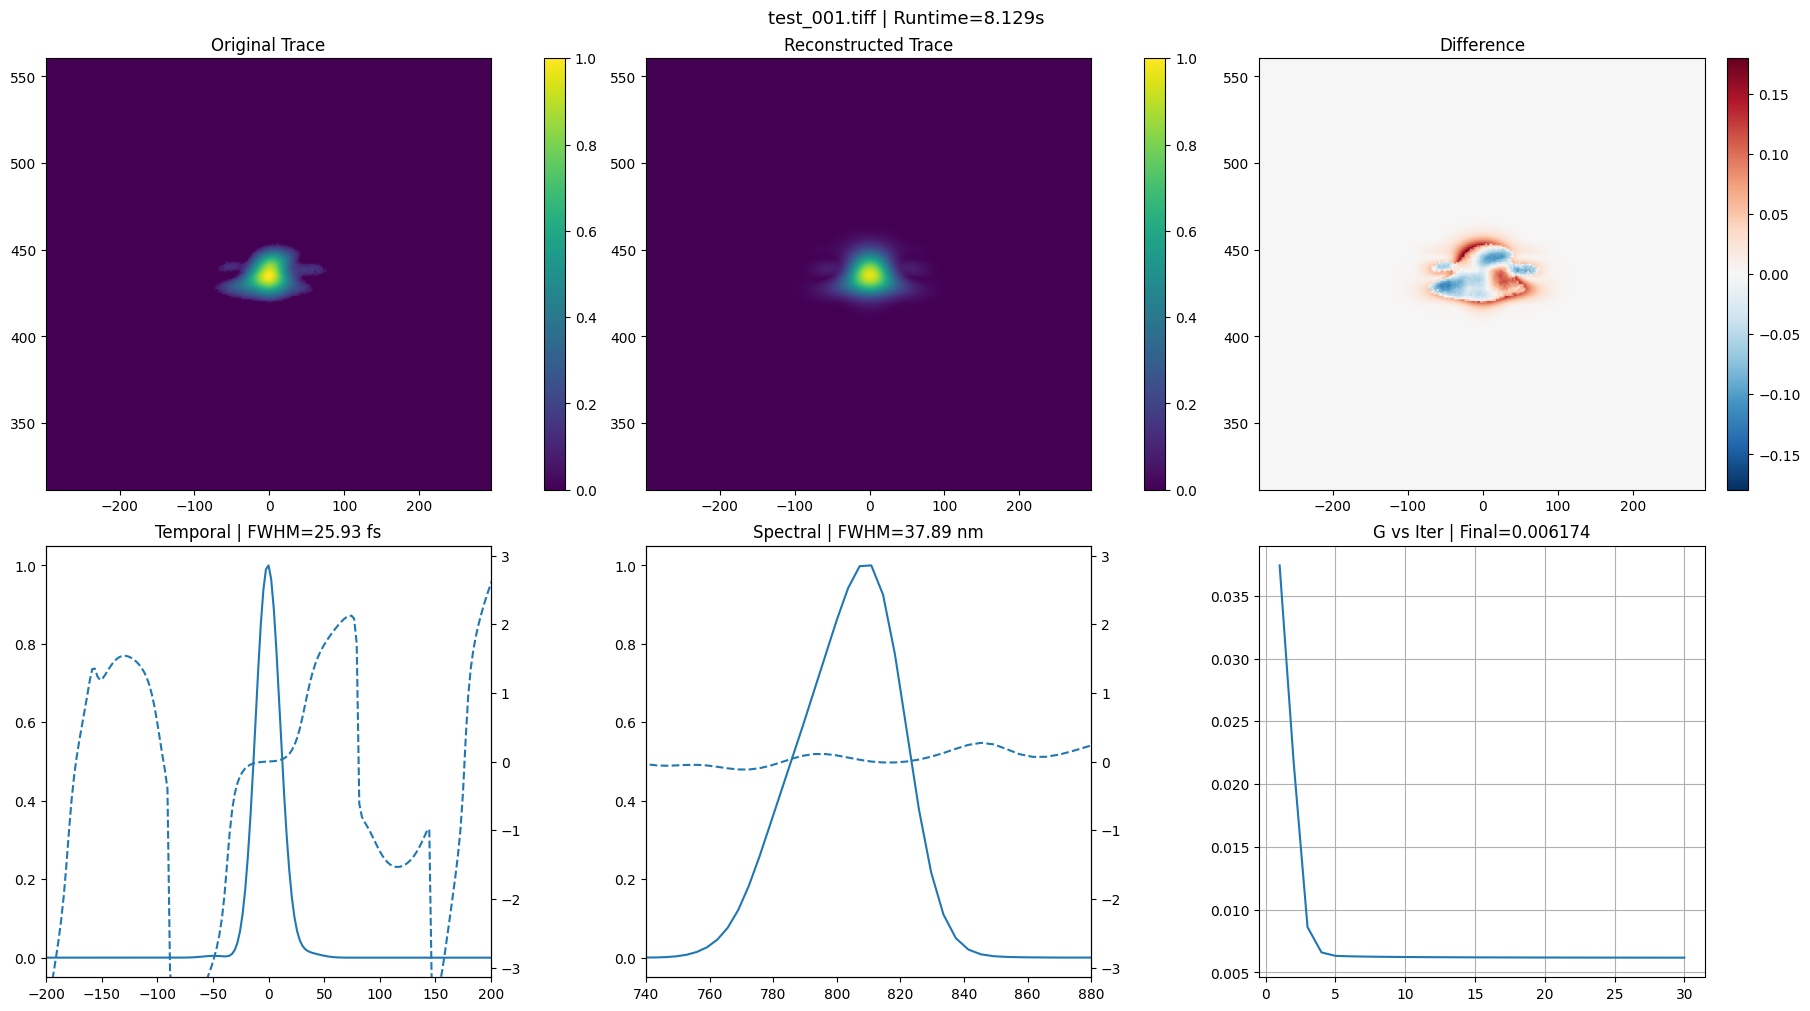

In [7]:
background_file=r"Z:\Data\2026_03_10_FROG\SSFROG_10Hz_50um_1inch_8mJ\Background_Gain28\BKFLY613__24492756__20260311_044808760_0077.tiff"
background_array = tiff.imread(background_file)

def find_latest_file(folder_path, keywords, match_all=True):
    """
    Find the most recently modified file in a folder
    whose name matches one or more keywords.

    :param folder_path: Path to the target folder
    :param keywords: List of substrings to search for in file names
    :param match_all: If True, file name must contain ALL keywords;
                      if False, file name can contain ANY keyword
    :return: Path object of the latest file, or None if not found
    """

    path = Path(folder_path)

    # Normalize keywords to a list (in case a single string is passed)
    if isinstance(keywords, str):
        keywords = [keywords]

    def matches(filename):
        """Check if filename matches keyword condition."""
        if match_all:
            return all(k in filename for k in keywords)
        else:
            return any(k in filename for k in keywords)

    # Collect matching files
    files = [
        f for f in path.iterdir()
        if f.is_file() and matches(f.name)
    ]

    if not files:
        return None

    # Return the file with the latest modification time
    return max(files, key=lambda f: f.stat().st_mtime)

# Example usage
folder = r"Z:\Data\2026_05_10_PlasmaMirrors_PhaseMeasurement\SSFROG_SI_test"
keyword = ["BKFLY613"]

ssfrog_file = find_latest_file(folder, keyword)
img_ssfrog = Image.open(ssfrog_file)
arr_ssfrog = np.array(img_ssfrog)
background_array = tiff.imread(background_file).astype(np.float32)
arr_ssfrog = arr_ssfrog.astype(np.float32)
array_background_removed = arr_ssfrog - background_array
array_background_removed = np.clip(array_background_removed, 1, None)
arr_ssfrog=array_background_removed
#make the x axis 1024, crop the right boundary if necessary
offset = (arr_ssfrog.shape[1] - 1024)/2
arr_ssfrog = arr_ssfrog[:, int(offset):int(offset)+1024].T
#print size and max value of the ssfrog_file
print("Size of SSFROG file:", arr_ssfrog.shape)
print("Max value of SSFROG file:", np.max(arr_ssfrog))
#show it
#plt.imshow(arr_ssfrog, cmap='gray')#perform RT on the selected SSFROG file, and plot the summary of the results.
result, eng = run_RT(
    input_array=arr_ssfrog,
    input_name="test_001",
    input_save_dir=r"D:\FROG_RT_Xuyang\Results\SSFROG_May2026\test",
    matlab_code_dir=r"Z:\Code\Experimental_Analysis\FROG\Frog_Automated",
    max_iter=30,
    plot_iter=30,
    temporal_calibration=0.387225,
    spectral_calibration=0.043919,
    background=5,
    central_wavelength=400,
    sz=256,
    width=70,
    verbose=True
)
#print and directly plot the result
print("Selected file:", result["selected_file"])
print("Final G:", result["final_G"])
print("Best G :", result["best_G"])

plot_rt_summary(result)